# Modelo más complejo

Este es el modelo más complejo que hemos planteado. Consistiendo con en 3 bloque de convolucionar,  normalización, dropout y max pooling, donde el tamaño del filtro va aumentando y el tamaño del kernel haciendose más pequeño. Posteriormente se encuentra una capa que Global pooling, que permite extraer las caracteristicass de la imagenes en un array unidimensional. A continuación esta un bloque de capas densas con normalización y dropout, empezando con 1024 neuronas que descienden a 256. Por ultimo esta la capa de salida que clasifica el resultado y hace la predicción.

Usa un optimizador de Descenso por gradiente estocástico con momento. 

### Impotacion y preprocesado de datos

In [1]:
from importacion_preprocesado import descarga_y_carga_de_datos, preprocesamiento


tamany_img = (128,128) # tamaño reducido para colab, porque si no supera la ram
X, y = descarga_y_carga_de_datos(target_size=tamany_img)

X_train, X_val, X_test, y_train, y_val, y_test = preprocesamiento(X, y)

Dataset ya existe, solo se van a cargar las imágenes.
X shape: (4217, 128, 128, 3) y shape: (4217,)


### Modelo

In [2]:
# Importar el modelo
import sys
sys.path.append('../')

from models.complejo_cnn import create_model

# Crear el modelo
model = create_model(input_shape=(128,128,3), num_classes=4, l_rate=0.0001)

c:\Users\roger\miniconda3\envs\dl\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

### Entrenamiento

In [ ]:
hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100
)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 505ms/step - accuracy: 0.2950 - loss: 3.9909 - val_accuracy: 0.3009 - val_loss: 3.3631
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 509ms/step - accuracy: 0.3333 - loss: 3.8745 - val_accuracy: 0.2737 - val_loss: 3.3552
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 526ms/step - accuracy: 0.3705 - loss: 3.6944 - val_accuracy: 0.2737 - val_loss: 3.4608
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 560ms/step - accuracy: 0.3911 - loss: 3.6508 - val_accuracy: 0.2737 - val_loss: 3.7351
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 471ms/step - accuracy: 0.4037 - loss: 3.5682 - val_accuracy: 0.2749 - val_loss: 4.1069
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 494ms/step - accuracy: 0.4081 - loss: 3.5449 - val_accuracy: 0.2749 - val_loss: 4.6148
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 472ms/step - accuracy: 0.4330 - loss: 3.4912 - val_accuracy: 0.2962 - val_loss: 4.4003
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 36s 450ms/step - accuracy: 0.4302 - loss: 3.5101 - 

### Resultados

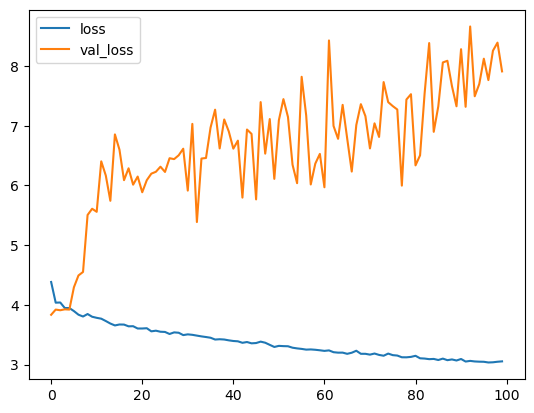

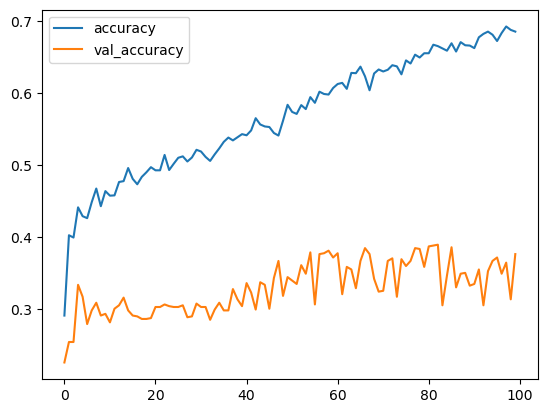

In [ ]:
import matplotlib.pyplot as plt
# Visualizacion evolucion loss durante el entrenamiento
plt.plot(hist.history['loss'],label="loss")
plt.plot(hist.history['val_loss'],label="val_loss")
plt.legend()
plt.show()

# Visualizacion de accuracy durante el entrenamiento
plt.plot(hist.history["accuracy"], label= "accuracy")
plt.plot(hist.history["val_accuracy"], label ="val_accuracy")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

datasets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test)
}

def evaluate(model, X, y):
    #Convertir a enteros
    y_true = np.argmax(y, axis=1)

    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1


def crear_df_metricas(model, datasets):
    results = {}
    for split_name, (X, y) in datasets.items():
        acc, f1 = evaluate(model, X, y)
        results[split_name] = [acc, f1]
    
    df = pd.DataFrame(results, index=["Accuracy", "F1"])
    return df

df = crear_df_metricas(model, datasets)
df.round(3)


80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


,Train,Val,Test
Accuracy,0.34,0.38,0.37
F1,0.23,0.26,0.26


In [ ]:
def plot_barra(metrica, titulo, color):

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrica.index, metrica.values, color=color)
    plt.bar_label(bars)
    plt.title(f"{titulo}: Train vs Validation vs Test")
    plt.ylabel(titulo)
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--')
    plt.show()


def plots_metricas(df):
    #Extraemos la fila
    accuracy = df.loc["Accuracy"]
    f1 = df.loc["F1"]

    #Grafico de Accuracy
    plot_barra(accuracy, titulo = "Accuracy", color="blue")

    #Grafico de 
    plot_barra(f1, titulo ="F1", color = "red")

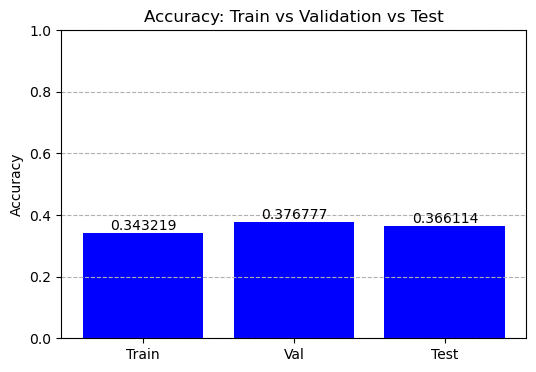

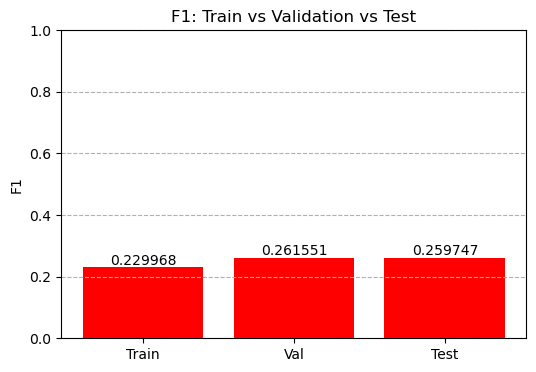

In [ ]:
plots_metricas(df)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


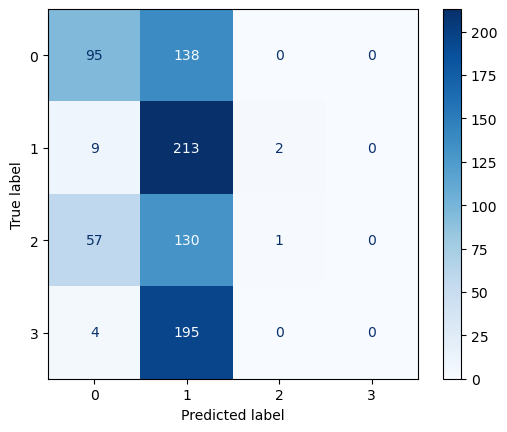

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm,  
                    display_labels= ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
                    ).plot(cmap="Blues", xticks_rotation= 45.0)

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def per_class_table(model, datasets):
    # class_names: lista con nombres de las clases en el orden de los índices (opcional)
    class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  

    splits = list(datasets.keys())
    # identificamos número de clases desde los datos si no dan nombres
    sample_X, sample_y = next(iter(datasets.values()))
    n_classes = np.argmax(sample_y, axis=1).max() + 1

    # DataFrame con index = clases y columnas por split/metric
    cols = []
    for s in splits:
        cols += [f"{s}_Accuracy", f"{s}_F1"]
    df = pd.DataFrame(index=class_names, columns=cols, dtype=float)

    for split in splits:
        X, y = datasets[split]
        y_true = np.argmax(y, axis=1)
        y_pred = np.argmax(model.predict(X), axis=1)

        # precision, recall, f1 por clase
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(n_classes), zero_division=0
        )
        # Aquí definimos "Accuracy" por clase como recall (TP / nº verdaderos de la clase)
        for i, cls in enumerate(class_names):
            df.loc[cls, f"{split}_Accuracy"] = recall[i]
            df.loc[cls, f"{split}_F1"] = f1[i]

    return df

df_per_class = per_class_table(model, datasets)
df_per_class.round(3)

80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


,Train_Accuracy,Train_F1,Val_Accuracy,Val_F1,Test_Accuracy,Test_F1
cataract,0.415,0.482,0.458,0.520,0.408,0.477
diabetic_retinopathy,0.961,0.453,0.970,0.491,0.951,0.473
glaucoma,0.000,0.000,0.005,0.010,0.005,0.010
normal,0.000,0.000,0.000,0.000,0.000,0.000


Pruebas durante el entrenamiento:

Con un learning rate de 0.001, no cenverje, teniendo la validación haciendo una montaña y un accuracy de media de 0.4 en validacion, tabla de resultados: 
            Train   Val  Test

Accuracy   0.45  0.44  0.45

F1         0.34  0.34  0.34
